In [1]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions


In [3]:
df = pd.DataFrame()

In [4]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]


In [5]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

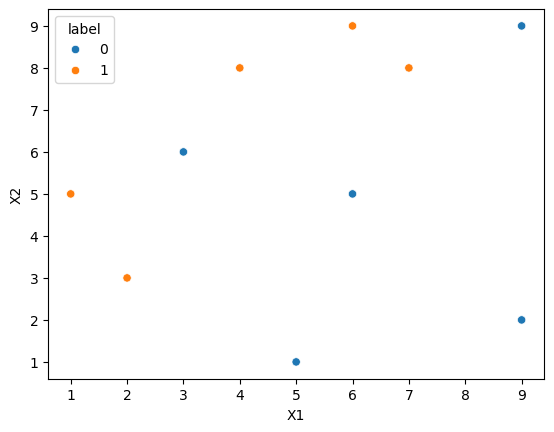

In [6]:
import seaborn as sns
sns.scatterplot(x = df['X1'],y=df['X2'],hue=df['label'])

In [7]:
df['weights'] = 1/df.shape[0]

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
from encodings import mac_arabic


clf = DecisionTreeClassifier(max_depth=1)

In [10]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [11]:
clf.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

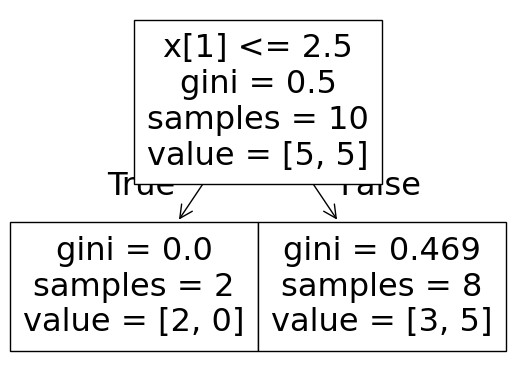

In [12]:
from sklearn.tree import plot_tree
plot_tree(clf)

<Axes: >

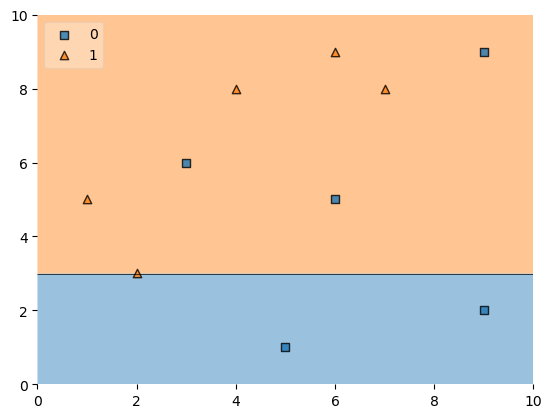

In [13]:
plot_decision_regions(X,y,clf=clf,legend=2)

In [14]:
df['y_pred'] = clf.predict(X)

In [15]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [16]:
def calculate_model_wt(error):
    return 0.5*np.log((1-error)/error)

In [17]:
# calculate model wt
alpha1 = calculate_model_wt(0.3)

In [18]:
alpha1

0.42364893019360184

In [20]:
# updated wt
def upadte_wt(row,alpha = 0.423):
    if(row['label'] == row['y_pred']):
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [21]:
df['updated_weight'] = df.apply(upadte_wt,axis=1)

In [22]:
df

,X1,X2,label,weights,y_pred,updated_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [23]:
df['updated_weight'].sum()

0.9165153319682015

In [ ]:
## normalize it to 1


In [25]:
df['normalise_weights'] = df['updated_weight']/df['updated_weight'].sum()

In [26]:
df

,X1,X2,label,weights,y_pred,updated_weight,normalise_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [27]:
df['normalise_weights'].sum()

1.0

In [28]:
df['cumsum_upper'] = np.cumsum(df['normalise_weights'])

In [29]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalise_weights']

In [30]:
df

,X1,X2,label,weights,y_pred,updated_weight,normalise_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [31]:
def create_new_dataset(df):
    indices = []
    
    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices
            

In [34]:
index_values = create_new_dataset(df)

In [35]:
index_values

[9, 1, 8, 7, 4, 6, 4, 0, 1, 1]

In [36]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [37]:
second_df

,X1,X2,label,weights
9,9,2,0,0.1
1,2,3,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
4,5,1,0,0.1
6,6,5,0,0.1
4,5,1,0,0.1
0,1,5,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1


In [38]:
clf2 = DecisionTreeClassifier(max_depth=1)

In [39]:
x = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [40]:
clf2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 3.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.625, 0.5, '  False')]

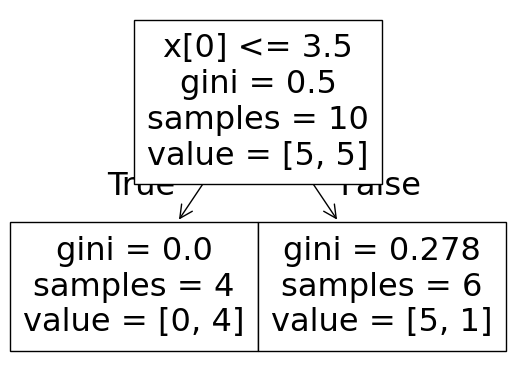

In [41]:
plot_tree(clf2)

<Axes: >

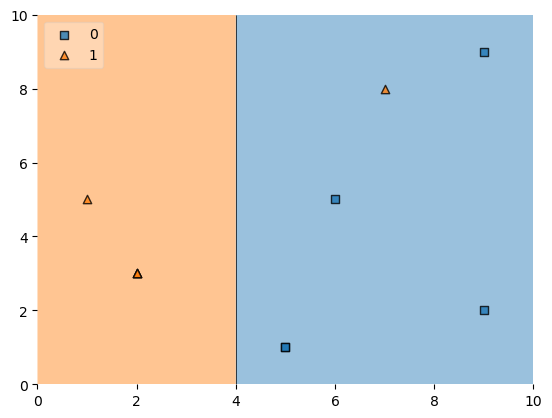

In [42]:
plot_decision_regions(x,y,clf=clf2,legend=2)

In [43]:
second_df['ypred'] = clf2.predict(x)

In [44]:
second_df

,X1,X2,label,weights,ypred
9,9,2,0,0.1,0
1,2,3,1,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,0
4,5,1,0,0.1,0
6,6,5,0,0.1,0
4,5,1,0,0.1,0
0,1,5,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
